In [140]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as  plt 
import seaborn 
from sklearn.model_selection import StratifiedShuffleSplit

In [141]:
titanic_dataset= pd.read_csv('train.csv')

In [142]:
titanic_dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [143]:
titanic_dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


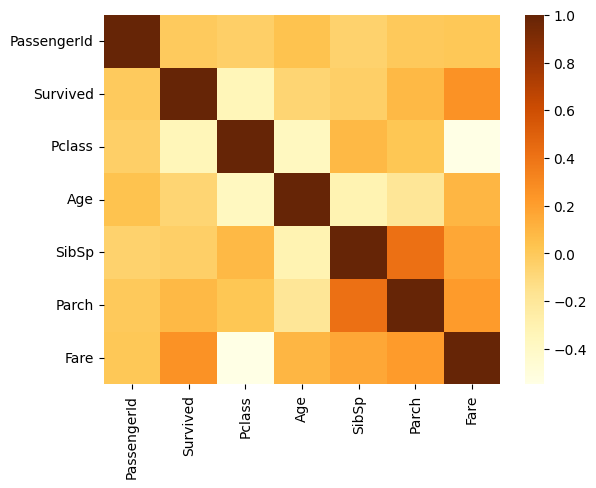

In [144]:
seaborn.heatmap(titanic_dataset.corr(numeric_only=True), cmap="YlOrBr")
plt.show()

In [145]:
# will randomly suffle the data set so we git 80% for learning and the other for testing 
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.25)
for train_indices, test_indices in split.split(titanic_dataset, titanic_dataset[["Survived","Pclass","Sex"]]):
    strat_train_set=titanic_dataset.loc[train_indices]
    strat_test_set=titanic_dataset.loc[test_indices]

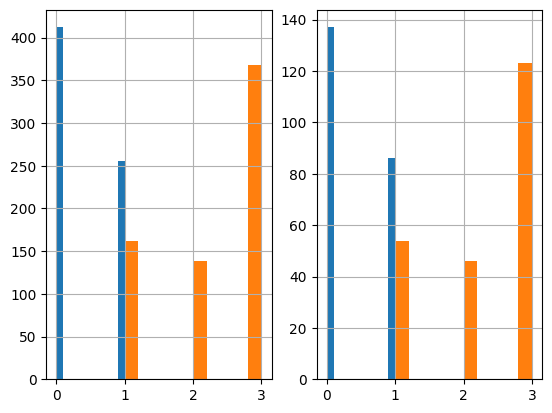

In [146]:
strat_train_set

plt.subplot(1,2,2)
strat_test_set["Survived"].hist()
strat_test_set["Pclass"]. hist()

plt.subplot(1,2,1)
strat_train_set["Survived"].hist()
strat_train_set["Pclass"]. hist()

plt.show()

In [147]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 139 to 312
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  668 non-null    int64  
 1   Survived     668 non-null    int64  
 2   Pclass       668 non-null    int64  
 3   Name         668 non-null    object 
 4   Sex          668 non-null    object 
 5   Age          534 non-null    float64
 6   SibSp        668 non-null    int64  
 7   Parch        668 non-null    int64  
 8   Ticket       668 non-null    object 
 9   Fare         668 non-null    float64
 10  Cabin        151 non-null    object 
 11  Embarked     667 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 67.8+ KB


In [148]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class ageimputer(BaseEstimator, TransformerMixin):
    
    def fit (self, X ,Y = None):
        return self
    def transform(self, X):
        imputer = SimpleImputer(strategy="mean")
        X["Age"]= imputer.fit_transform(X[["Age"]])
        return X 

In [149]:
from sklearn.preprocessing import OneHotEncoder


class FeatureEncoder(BaseEstimator, TransformerMixin):
    def fit (self, X ,Y = None):
        return self
    def transform(self, X):
        encoder = OneHotEncoder()
        matrix = encoder.fit_transform(X[["Embarked"]]).toarray()
        
        column_name = ["C","S","Q","N"]
        
        for i in range(len(matrix.T)):
            X[column_name[i]] = matrix.T[i]
    
        matrix = encoder.fit_transform(X[["Sex"]]).toarray()
        column_name=["Female","Male"]
            
        for i in range(len(matrix.T)):
            X[column_name[i]] = matrix.T[i]
            
        return X
            
            
            
    

In [150]:
class feacherDroper(BaseEstimator, TransformerMixin):
    def fit (self, X ,Y = None):
        return self
    
    def transform(self, X):
        z = X.drop(["Embarked","Name","Ticket","Cabin","Sex","N"],axis=1, errors="ignore")
        return z

In [151]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([("ageimputer", ageimputer()),
                     ("featureencoder", FeatureEncoder()),
                     ("feacherdroper", feacherDroper())
                     
                     
                     ])

In [152]:
strat_train_set=pipeline.fit_transform(strat_train_set)

In [153]:
strat_test_set

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
728,729,0,2,"Bryhl, Mr. Kurt Arnold Gottfrid",male,25.0,1,0,236853,26.0000,NaN,S
655,656,0,2,"Hickman, Mr. Leonard Mark",male,24.0,2,0,S.O.C. 14879,73.5000,NaN,S
832,833,0,3,"Saad, Mr. Amin",male,NaN,0,0,2671,7.2292,NaN,C
487,488,0,1,"Kent, Mr. Edward Austin",male,58.0,0,0,11771,29.7000,B37,C
416,417,1,2,"Drew, Mrs. James Vivian (Lulu Thorne Christian)",female,34.0,1,1,28220,32.5000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
172,173,1,3,"Johnson, Miss. Eleanor Ileen",female,1.0,1,1,347742,11.1333,NaN,S
162,163,0,3,"Bengtsson, Mr. John Viktor",male,26.0,0,0,347068,7.7750,NaN,S
306,307,1,1,"Fleming, Miss. Margaret",female,NaN,0,0,17421,110.8833,NaN,C
686,687,0,3,"Panula, Mr. Jaako Arnold",male,14.0,4,1,3101295,39.6875,NaN,S


In [154]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 139 to 312
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  668 non-null    int64  
 1   Survived     668 non-null    int64  
 2   Pclass       668 non-null    int64  
 3   Age          668 non-null    float64
 4   SibSp        668 non-null    int64  
 5   Parch        668 non-null    int64  
 6   Fare         668 non-null    float64
 7   C            668 non-null    float64
 8   S            668 non-null    float64
 9   Q            668 non-null    float64
 10  Female       668 non-null    float64
 11  Male         668 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 67.8 KB


In [155]:
# the data in the format i need 
from sklearn.preprocessing import StandardScaler

x= strat_train_set.drop(["Survived"], axis=1)
y = strat_train_set["Survived"]

scaler=StandardScaler()
x_data = scaler.fit_transform(x)
y_data = y.to_numpy()


In [133]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV

classify = RandomForestClassifier()

param_grid= [{ "n_estimators": [10 ,100 , 200 , 500], "max_depth":[None,5 , 10 ], "min_samples_split":[2,3,4]}]

grid_search = GridSearchCV(classify, param_grid, cv=3,scoring="accuracy", return_train_score=True)

grid_search.fit(x_data,y_data)


GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [134]:
final_classif = grid_search.best_estimator_

In [135]:
strat_test_set = pipeline.fit_transform(strat_test_set)


In [136]:
x= strat_test_set.drop(["Survived"], axis=1)
y = strat_test_set["Survived"]

scaler=StandardScaler()
x_data_test = scaler.fit_transform(x)
y_data_test = y.to_numpy()

In [137]:
final_classif.score(x_data_test,y_data_test)

0.726457399103139

In [138]:
final_data=pipeline.fit_transform(titanic_dataset)
final_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
0,1,0,3,22.000000,1,0,7.2500,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.000000,1,0,71.2833,1.0,0.0,0.0,1.0,0.0
2,3,1,3,26.000000,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.000000,1,0,53.1000,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.000000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
887,888,1,1,19.000000,0,0,30.0000,0.0,0.0,1.0,1.0,0.0
888,889,0,3,29.699118,1,2,23.4500,0.0,0.0,1.0,1.0,0.0
889,890,1,1,26.000000,0,0,30.0000,1.0,0.0,0.0,0.0,1.0


In [139]:
x_final = final_data.drop(["Survived"], axis = 1)
y_final = final_data["Survived"]

scaler = StandardScaler()
x_data_final = scaler.fit_transform(x_final)
y_data_final = y_final.to_numpy()


In [156]:
pro_cassif=RandomForestClassifier()


param_grid= [{ "n_estimators": [10 ,100 , 200 , 500], "max_depth":[None,5 , 10 ], "min_samples_split":[2,3,4]}]

grid_search = GridSearchCV(classify, param_grid, cv=3,scoring="accuracy", return_train_score=True)

grid_search.fit(x_data_final,y_data_final)




GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [157]:
pro_final_classif= grid_search.best_estimator_
pro_final_classif

RandomForestClassifier(max_depth=10, n_estimators=200)

In [163]:
titanic_dataset_test = pd.read_csv("test.csv")
final_titanic_test_data= pipeline.fit_transform(titanic_dataset_test)

In [ ]:
#--------
x_final_test = final_titanic_test_data
x_final_test = x_final_test.ffill()

scaler = StandardScaler()
x_data_final_test= scaler.fit_transform(x_final_test)

In [169]:
predictions = pro_final_classif.predict(x_data_final_test)
predictions

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [170]:
pipeline.steps


[('ageimputer', ageimputer()),
 ('featureencoder', FeatureEncoder()),
 ('feacherdroper', feacherDroper())]

In [171]:
final_df = pd.DataFrame(titanic_dataset_test["PassengerId"])
final_df["Survived"]= predictions
final_df.to_csv("predictions.csv", index=False)
final_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
